In [1]:
import jax
import jax.numpy as jnp
import jax.random as jrandom

#jax.config.update("jax_platform_name", "cpu")

import matplotlib.pyplot as plt

from probjax.utils.odeint import _odeint
from probjax.utils.jaxutils import ravel_args
from probjax.core import joint_sample, log_potential_fn,rv 
from probjax.distributions import Normal, Uniform, Independent
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.inference.mcmc import MCMC 
from probjax.inference.marcov_kernels import HMCKernel, GaussianMHKernel, SliceKernel, LangevianMHKernel

from functools import partial

In [2]:


def drift_lotka_volterra(t, data, alpha,beta, gamma, delta):
    predator, prey = data
    d_predator = alpha * predator - beta * predator * prey
    d_prey = -gamma * prey + delta * predator * prey
    return d_predator, d_prey

num_timeponts = 48
max_num_nodes = 4 + 2*num_timeponts
time_start = 0
time_end = 20
ts_dense = jnp.linspace(time_start, time_end, 200)

def simulator(thetas):
    theta1, theta2, theta3, theta4 = jnp.split(thetas, 4, axis=-1)
    predator, prey = jax.vmap(lambda *args: _odeint(*args), in_axes=(None, None, None, 0,0,0,0))(drift_lotka_volterra, (1., 0.5), ts_dense, theta1, theta2, theta3, theta4)
    return predator, prey


def generate_dense_data(key, n):
    key1, key2, key3, key4, key5, key6 = jrandom.split(key, 6)

    theta1 = jax.nn.sigmoid(jrandom.normal(key1, (n,1)))*2 + 1.
    theta2 = jax.nn.sigmoid(jrandom.normal(key2, (n,1)))*2 + 1.
    theta3 = jax.nn.sigmoid(jrandom.normal(key3, (n,1)))*2 + 1.
    theta4 = jax.nn.sigmoid(jrandom.normal(key4, (n,1)))*2 + 1.
    
    predator, prey = jax.vmap(lambda *args: _odeint(*args), in_axes=(None, None, None, 0,0,0,0))(drift_lotka_volterra, (1., 0.5), ts_dense, theta1, theta2, theta3, theta4)
    thetas = jnp.concatenate([theta1, theta2, theta3, theta4], axis=-1)
    return thetas, predator, prey


#with jax.default_device(cpu):
thetas, predator, prey = generate_dense_data(jrandom.PRNGKey(0), 10)


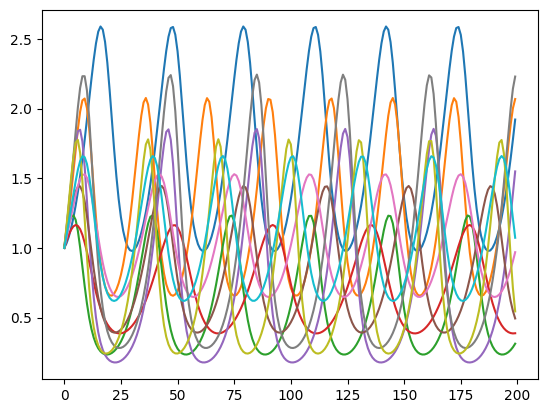

In [3]:
_ = plt.plot(predator.T)

In [4]:
def model(key, ts1, ts2, ode_method="rk4", ode_ts_grid=ts_dense):
    key_theta0, key_theta1, key_theta2, key_theta3, key_predator, key_prey = jrandom.split(key, 6)
    prior = TransformedDistribution(Normal(jnp.zeros(1), jnp.ones(1)), lambda x: jax.nn.sigmoid(x)*2 + 1.)
    theta0 = rv(prior, name="theta0")(key_theta0)
    theta1 = rv(prior, name="theta1")(key_theta1)
    theta2 = rv(prior, name="theta2")(key_theta2)
    theta3 = rv(prior, name="theta3")(key_theta3)
    
    predator, prey = _odeint(drift_lotka_volterra, (1., 0.5), ode_ts_grid, theta0, theta1, theta2, theta3, method=ode_method)
    
    predator_observed_mean = jnp.interp(ts1, ode_ts_grid, predator)
    prey_observed_mean = jnp.interp(ts2, ode_ts_grid, prey)
    
    x0 = rv(Independent(Normal(predator_observed_mean, 0.01),1), name="x0")(key_predator)
    x1 = rv(Independent(Normal(prey_observed_mean, 0.01),1), name="x1")(key_prey)
    
    

In [5]:
joint_sampler = joint_sample(model)

In [6]:
var_names = ["theta0", "theta1", "theta2", "theta3", "x0", "x1"]

In [8]:
@partial(jax.vmap, in_axes = [0, None, None, None, None])
def sample_fn(key, condition_mask, x_o, x_meta_data):

    conditioned_names = [var_names[i] for i in range(len(var_names)) if condition_mask[i]]
    conditioned_nodes = {var: val for var, val in zip(conditioned_names, x_o)}
    

    init_vals = joint_sampler(key, x_meta_data)

    for var in conditioned_nodes:
        del init_vals[var]

    init_vals_flat, unravel = ravel_args(init_vals)
    potential_fn = log_potential_fn(joint_sampler, x_meta_data)


    @jax.jit
    def potential_fn_wrapper(vals):
        vals = unravel(vals)
        return potential_fn(**vals, **conditioned_nodes)

    kernel = HMCKernel(step_size=1e-8)
    kernel2 = GaussianMHKernel(step_size=0.5)
    state = kernel.init_state(key,init_vals_flat)
    mcmc = MCMC(kernel, potential_fn_wrapper)
    mcmc2 = MCMC(kernel2, potential_fn_wrapper)
    samples, state = mcmc.run(state, 200)
    samples, state = mcmc2.run(state, 2000)
    return samples

In [7]:
sample = joint_sampler(jax.random.PRNGKey(1), ts_dense,ts_dense)

ValueError: safe_map() argument 2 is shorter than argument 1

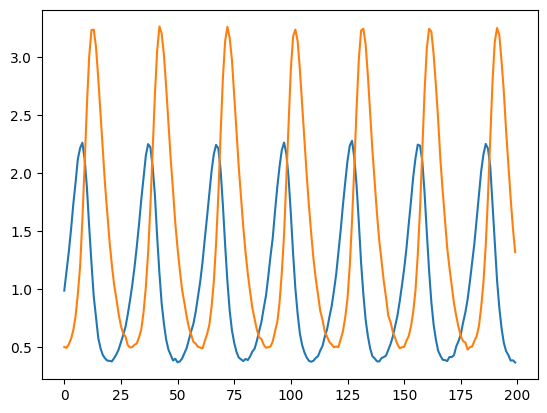

In [9]:
plt.plot(sample["x0"])
plt.plot(sample["x1"])

In [10]:
keys = jrandom.split(jrandom.PRNGKey(0), 1000)

In [11]:
observe_every= 5
samples = sample_fn(keys, jnp.array([False, False, False, False, True, True]), (sample["x0"][::observe_every], sample["x1"][::observe_every]), ts_dense[::observe_every], ts_dense[::observe_every])

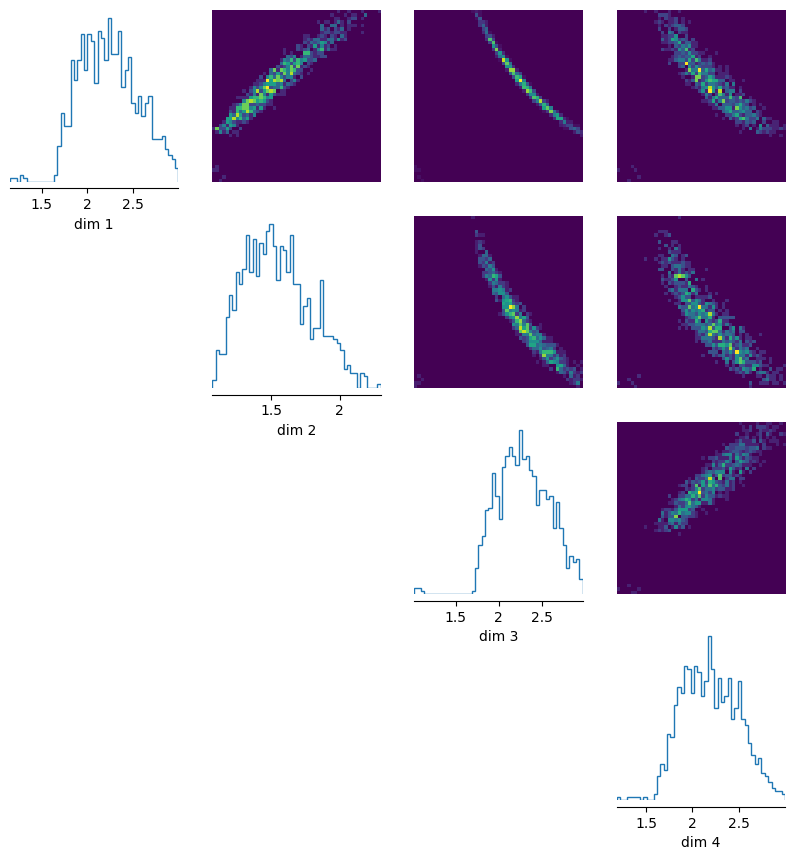

In [12]:
from sbi.analysis import pairplot
import numpy as np


_ = pairplot(np.array(samples))

In [13]:
sample = joint_sampler(jax.random.PRNGKey(1), ts_dense,ts_dense)

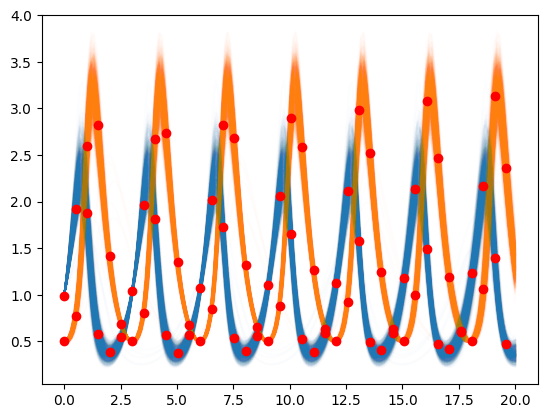

In [14]:
predator, prey = simulator(samples)

_ = plt.plot(ts_dense,predator.T, color="C0", alpha=0.01)
_ = plt.plot(ts_dense,prey.T, color="C1", alpha=0.01)
_ = plt.plot(ts_dense[::observe_every], sample["x0"][::observe_every], "o", color="red")
_ = plt.plot(ts_dense[::observe_every], sample["x1"][::observe_every], "o", color="red")